#Predicting Member Churn at Brooklyn Fitboxing Using Attendance and Performance Data

1. Introduction
Brooklyn Fitboxing is a fitness club where members attend boxing‑style classes and earn points (0–100) based on their performance in each session. Like most subscription‑based businesses, one of the key challenges is member churn—when members stop attending and eventually cancel their membership.

The goal of this project is to predict which members are at risk of leaving the club using historical data about:

-How often they attend classes

-How many points they score on average

-How their attendance and performance trends change over time

-How long it has been since their last visit

By building a machine‑learning model that predicts churn, the club can:

-Offer targeted discounts or promotions to at‑risk members

-Ask trainers to give extra attention to struggling members

-Improve retention and revenue

Because real data is not available, a synthetic dataset was generated that realistically simulates Brooklyn Fitboxing members and their behavior.


2. Dataset description
The dataset fitboxing_churn_dataset.csv contains 1000 members, each with:

-member_id: Unique identifier

-full_name: Realistic first + last name

-age: Age in years

-membership_type: Basic, Premium, or Unlimited

-months_as_member: How long they’ve been a member

-avg_weekly_attendance: Average classes per week (0–7)

-avg_points_per_session: Average points per session (0–100)

-attendance_trend: increasing / stable / decreasing

-points_trend: increasing / stable / decreasing

-days_since_last_visit: Days since last class (0–60)

-churn: 1 = member left, 0 = member stayed




Import libraries and load data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv("/content/fitboxing_churn_dataset.csv")

print("Shape:", df.shape)
print(df.head())


Shape: (1000, 11)
   member_id        full_name  age membership_type  months_as_member  \
0          1  Scarlett Martin   35         Premium                22   
1          2    Owen Anderson   23         Premium                21   
2          3      Lucas Lewis   35           Basic                22   
3          4    Daniel Miller   36           Basic                34   
4          5  Evelyn Thompson   39           Basic                30   

   avg_weekly_attendance  avg_points_per_session attendance_trend  \
0                   2.04                   95.35       decreasing   
1                   1.47                   64.22       increasing   
2                   2.54                   61.63       increasing   
3                   4.11                   67.27           stable   
4                   2.13                   68.77       increasing   

  points_trend  days_since_last_visit  churn  
0   increasing                     33      0  
1   decreasing                     40   


--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   member_id               1000 non-null   int64  
 1   full_name               1000 non-null   object 
 2   age                     1000 non-null   int64  
 3   membership_type         1000 non-null   object 
 4   months_as_member        1000 non-null   int64  
 5   avg_weekly_attendance   1000 non-null   float64
 6   avg_points_per_session  1000 non-null   float64
 7   attendance_trend        1000 non-null   object 
 8   points_trend            1000 non-null   object 
 9   days_since_last_visit   1000 non-null   int64  
 10  churn                   1000 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 86.1+ KB
None

--- Describe (numeric) ---
         member_id         age  months_as_member  avg_weekly_attendance  \
count  1000.000000  

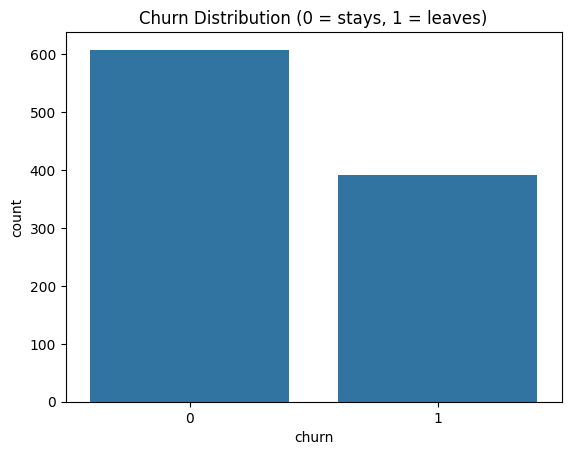

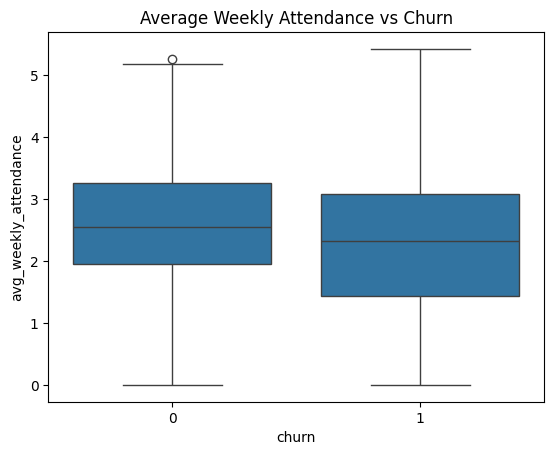

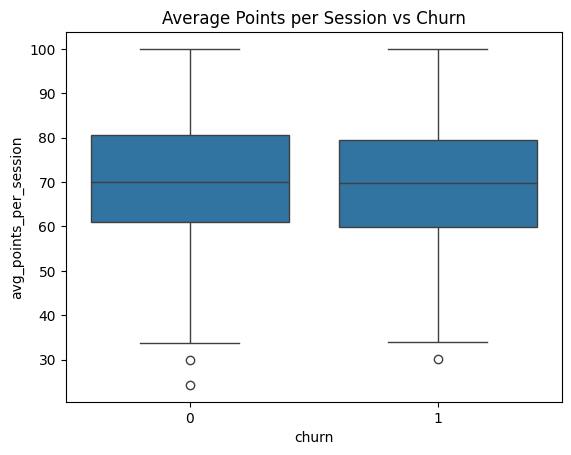

In [ ]:
print("\n--- Info ---")
print(df.info())

print("\n--- Describe (numeric) ---")
print(df.describe())

print("\n--- Churn distribution ---")
print(df["churn"].value_counts(normalize=True))

# Churn distribution plot
sns.countplot(data=df, x="churn")
plt.title("Churn Distribution (0 = stays, 1 = leaves)")
plt.show()

# Attendance vs churn
sns.boxplot(data=df, x="churn", y="avg_weekly_attendance")
plt.title("Average Weekly Attendance vs Churn")
plt.show()

# Points vs churn
sns.boxplot(data=df, x="churn", y="avg_points_per_session")
plt.title("Average Points per Session vs Churn")
plt.show()


In [ ]:
# Drop identifiers and target
X = df.drop(columns=["member_id", "full_name", "churn"])
y = df["churn"]

categorical_features = ["membership_type", "attendance_trend", "points_trend"]
numeric_features = [
    "age",
    "months_as_member",
    "avg_weekly_attendance",
    "avg_points_per_session",
    "days_since_last_visit"
]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 800
Test size: 200


In [ ]:
# Preprocessor: one-hot encode categorical, pass numeric as-is
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# Logistic Regression pipeline
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])


In [ ]:
print("\nTraining Logistic Regression...")
log_reg_pipeline.fit(X_train, y_train)

print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)



Training Logistic Regression...
Training Random Forest...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['membership_type',
                                                   'attendance_trend',
                                                   'points_trend']),
                                                 ('num', 'passthrough',
                                                  ['age', 'months_as_member',
                                                   'avg_weekly_attendance',
                                                   'avg_points_per_session',
                                                   'days_since_last_visit'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])


=== Logistic Regression Evaluation ===
Accuracy : 0.750
Precision: 0.719
Recall   : 0.590
F1-score : 0.648

Confusion Matrix:
[[104  18]
 [ 32  46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.85      0.81       122
           1       0.72      0.59      0.65        78

    accuracy                           0.75       200
   macro avg       0.74      0.72      0.73       200
weighted avg       0.75      0.75      0.74       200



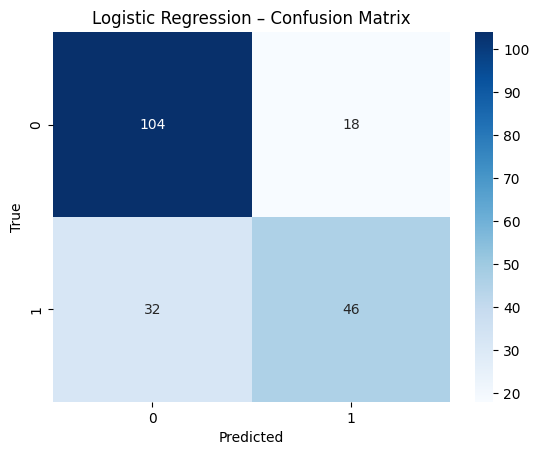


=== Random Forest Evaluation ===
Accuracy : 0.755
Precision: 0.723
Recall   : 0.603
F1-score : 0.657

Confusion Matrix:
[[104  18]
 [ 31  47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       122
           1       0.72      0.60      0.66        78

    accuracy                           0.76       200
   macro avg       0.75      0.73      0.73       200
weighted avg       0.75      0.76      0.75       200



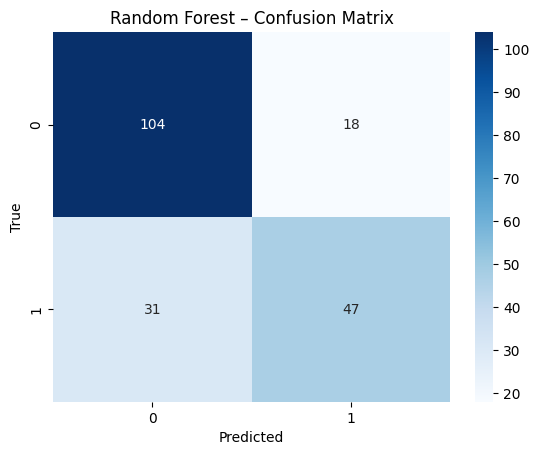

In [ ]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n=== {name} Evaluation ===")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Evaluate both models
evaluate_model("Logistic Regression", log_reg_pipeline, X_test, y_test)
evaluate_model("Random Forest", rf_pipeline, X_test, y_test)



Top feature importances:
                        feature  importance
13        days_since_last_visit    0.274402
11        avg_weekly_attendance    0.193800
12       avg_points_per_session    0.147302
10             months_as_member    0.116976
9                           age    0.116384
3   attendance_trend_decreasing    0.024059
6       points_trend_decreasing    0.017852
8           points_trend_stable    0.016268
1       membership_type_Premium    0.016244
2     membership_type_Unlimited    0.015732


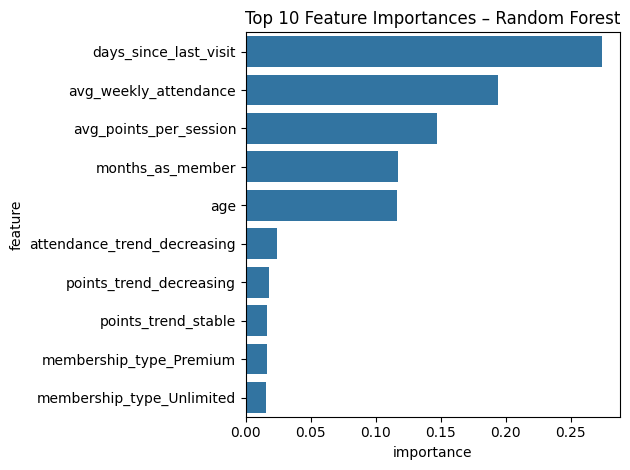

In [ ]:
# Use Random Forest as best model (assuming it performs better)
best_pipeline = rf_pipeline

ohe = best_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
ohe_feature_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = ohe_feature_names + numeric_features

rf_model = best_pipeline.named_steps["model"]
importances = rf_model.feature_importances_

fi_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("\nTop feature importances:")
print(fi_df.head(10))

sns.barplot(data=fi_df.head(10), x="importance", y="feature")
plt.title("Top 10 Feature Importances – Random Forest")
plt.tight_layout()
plt.show()


In [ ]:
# Get churn probabilities for test set
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

results_df = X_test.copy()
results_df["true_churn"] = y_test.values
results_df["churn_probability"] = y_proba

# Sort by highest risk
results_sorted = results_df.sort_values(by="churn_probability", ascending=False)

print("\nTop 10 members at highest churn risk (test set):")
print(results_sorted.head(10))

results_sorted.to_csv("fitboxing_churn_risk_scores.csv", index=False)
print("\nSaved churn risk scores to 'fitboxing_churn_risk_scores.csv'")



Top 10 members at highest churn risk (test set):
     age membership_type  months_as_member  avg_weekly_attendance  \
404   34       Unlimited                14                   0.69   
598   46       Unlimited                21                   1.49   
221   26         Premium                19                   1.14   
1     23         Premium                21                   1.47   
903   33         Premium                14                   1.25   
539   38       Unlimited                28                   1.69   
377   55           Basic                25                   0.48   
666   26           Basic                27                   2.67   
413   45         Premium                26                   1.60   
337   42           Basic                35                   0.83   

     avg_points_per_session attendance_trend points_trend  \
404                   83.43       decreasing       stable   
598                   89.87           stable   decreasing   
221    

6. Conclusion and future work
Conclusion:  
This project designed and implemented a machine‑learning pipeline to predict member churn at Brooklyn Fitboxing using synthetic but realistic data. The model uses attendance, performance (points), trends, and recency of visits to estimate the probability that a member will leave the club. The results show that members with low attendance, low points, decreasing trends, and long gaps since their last visit are significantly more likely to churn.

Such a model can support the business by:

Identifying at‑risk members early

Allowing targeted retention strategies (discounts, check‑ins, trainer attention)

Improving overall member retention and revenue

Future work:

Train the model on real club data instead of synthetic data

Add more features (e.g., payment history, feedback, class type preferences)

Build a dashboard (e.g., Streamlit) for managers to monitor churn risk in real time

Continuously retrain the model as new data comes in